# 二元线性回归的 3D 图示

## 1. 这类图形本质上是什么

你图里的内容，本质上是一个三维回归可视化图。通常对应的模型是：

$$
y_i = \beta_0 + \beta_1 x_{1i} + \beta_2 x_{2i} + u_i
$$

拟合后得到预测平面：

$$
\hat y_i = \hat\beta_0 + \hat\beta_1 x_{1i} + \hat\beta_2 x_{2i}
$$

如果选择的是 `vertical （Y）` 距离，那么每个点到平面的“距离”其实就是纵向残差：

$$
e_i = y_i - \hat y_i
$$

也就是说：

* 黑点：真实观测值
* 蓝色半透明平面：拟合平面
* 竖线：从真实点到预测点的残差
* 红点：落在平面上的预测点

这类图，Python 不但能画，而且有两种常用途径：

* `matplotlib`：适合静态图片、论文插图、讲义
* `plotly`：更接近你截图里的交互式效果，可以旋转、缩放、悬停显示

## 2. 最直接的 Python 实现

下面这段代码可以直接画出“散点 + 回归平面 + 竖直残差线”的效果。



In [ ]:
# ============================================
# 3D 回归平面 + 垂直残差线示例
# ============================================

#!pip install mplot3d

import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------
# 1. 生成一组模拟数据
#    模型设定：
#    y = 0.5 + 0.8*x1 - 0.4*x2 + error
# ------------------------------------------------
np.random.seed(123)

n = 50
x1 = np.random.uniform(-2, 2, n)
x2 = np.random.uniform(-2, 2, n)
error = np.random.normal(0, 0.6, n)

y = 0.5 + 0.8 * x1 - 0.4 * x2 + error

# 将自变量整理成二维数组，便于回归拟合
X = np.column_stack([x1, x2])

# ------------------------------------------------
# 2. 拟合线性回归模型
# ------------------------------------------------
model = LinearRegression()
model.fit(X, y)

# 计算样本点的预测值
y_hat = model.predict(X)

# 输出估计结果，便于核对
print("截距项 =", model.intercept_)
print("斜率系数 =", model.coef_)

# ------------------------------------------------
# 3. 构造回归平面所需的网格点
# ------------------------------------------------
x1_grid = np.linspace(x1.min(), x1.max(), 30)
x2_grid = np.linspace(x2.min(), x2.max(), 30)

X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

# 按照估计出的回归方程，计算网格上的预测值
Y_grid = (
    model.intercept_
    + model.coef_[0] * X1_grid
    + model.coef_[1] * X2_grid
)


截距项 = 0.5414040723184379
斜率系数 = [ 0.77776463 -0.57227678]


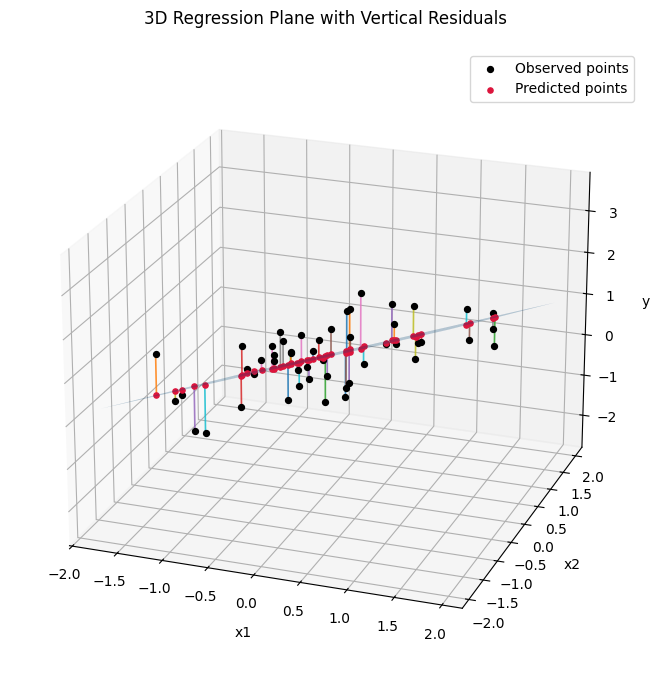

In [3]:

# ------------------------------------------------
# 4. 开始绘图
# ------------------------------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection='3d')

# （1）绘制半透明的回归平面
ax.plot_surface(
    X1_grid,
    X2_grid,
    Y_grid,
    alpha=0.30,
    edgecolor='none'
)

# （2）绘制真实观测点（黑色）
ax.scatter(
    x1, x2, y,
    s=18,
    c='black',
    depthshade=False,
    label='Observed points'
)

# （3）绘制预测点（红色，位于平面上）
ax.scatter(
    x1, x2, y_hat,
    s=14,
    c='crimson',
    depthshade=False,
    label='Predicted points'
)

# （4）绘制竖直残差线
#     因为是 vertical（Y） distance，
#     所以固定 x1 和 x2，只连接 y 与 y_hat
for i in range(n):
    ax.plot(
        [x1[i], x1[i]],      # x1 不变
        [x2[i], x2[i]],      # x2 不变
        [y[i], y_hat[i]],    # 从真实 y 连到预测 y_hat
        linewidth=1.2,
        alpha=0.85
    )

# ------------------------------------------------
# 5. 坐标轴与视角设置
# ------------------------------------------------
ax.set_xlabel('x1', labelpad=8)
ax.set_ylabel('x2', labelpad=8)
ax.set_zlabel('y',  labelpad=8)

ax.set_title('3D Regression Plane with Vertical Residuals', pad=18)

# 调整视角，使图形更接近常见教学演示效果
ax.view_init(elev=22, azim=-70)

plt.legend()
plt.tight_layout()
plt.show()


### 三维回归可视化的完整代码示例


In [8]:
# ============================================================
# 讲义版：三维回归平面、真实平面、拟合平面与竖直残差
# 说明：
# 1. 图 1：真实平面 + 样本点
# 2. 图 2：拟合平面 + 预测点 + 竖直残差
# 3. 使用 plotly 生成交互式图形，适合课堂演示
# ============================================================

import numpy as np
from sklearn.linear_model import LinearRegression
import plotly.graph_objects as go

# 创建 ./figs 子文件夹，用于保存生成的 HTML 图形
import os
if not os.path.exists('./figs'):
    os.makedirs('./figs')


# ------------------------------------------------------------
# 1. 生成模拟数据
#    这里设定一个“真实”的线性关系：
#    y = beta0 + beta1*x1 + beta2*x2 + error
# ------------------------------------------------------------
np.random.seed(123)

# 样本量
n = 60

# 生成两个自变量
x1 = np.random.uniform(-2.2, 2.2, n)
x2 = np.random.uniform(-2.2, 2.2, n)

# 真实参数
beta0_true = 0.5
beta1_true = 0.8
beta2_true = -0.4

# 随机扰动项
eps = np.random.normal(loc=0, scale=0.55, size=n)

# 真实平面上的“无误差部分”
y_true_plane = beta0_true + beta1_true * x1 + beta2_true * x2

# 实际观测值
y = y_true_plane + eps

# ------------------------------------------------------------
# 2. 拟合线性回归模型
# ------------------------------------------------------------
X = np.column_stack([x1, x2])

model = LinearRegression()
model.fit(X, y)

# 样本点的拟合值
y_hat = model.predict(X)

print("真实参数：")
print(f"beta0 = {beta0_true:.4f}, beta1 = {beta1_true:.4f}, beta2 = {beta2_true:.4f}")

print("\nOLS 估计结果：")
print(f"beta0_hat = {model.intercept_:.4f}")
print(f"beta1_hat = {model.coef_[0]:.4f}")
print(f"beta2_hat = {model.coef_[1]:.4f}")

# ------------------------------------------------------------
# 3. 构造网格点
#    用于绘制“真实平面”和“拟合平面”
# ------------------------------------------------------------
x1_grid = np.linspace(x1.min(), x1.max(), 35)
x2_grid = np.linspace(x2.min(), x2.max(), 35)
X1_grid, X2_grid = np.meshgrid(x1_grid, x2_grid)

# 真实平面
Y_true_grid = beta0_true + beta1_true * X1_grid + beta2_true * X2_grid

# 拟合平面
Y_hat_grid = (
    model.intercept_
    + model.coef_[0] * X1_grid
    + model.coef_[1] * X2_grid
)

# ============================================================
# 图 1：真实平面 + 样本点
# ============================================================
fig1 = go.Figure()

# 真实平面
fig1.add_trace(
    go.Surface(
        x=X1_grid,
        y=X2_grid,
        z=Y_true_grid,
        opacity=0.45,
        showscale=False,
        name="True plane"
    )
)

# 样本点
fig1.add_trace(
    go.Scatter3d(
        x=x1,
        y=x2,
        z=y,
        mode="markers",
        marker=dict(
            size=3,
            color="black"
        ),
        name="Observed points"
    )
)

# 可选：在样本点对应位置，标出“真实平面上的点”
# 这样读者可以更直观看到误差项的含义
fig1.add_trace(
    go.Scatter3d(
        x=x1,
        y=x2,
        z=y_true_plane,
        mode="markers",
        marker=dict(
            size=3,
            color="royalblue"
        ),
        name="Points on true plane"
    )
)

# 误差线：从真实平面到观测点
for i in range(n):
    fig1.add_trace(
        go.Scatter3d(
            x=[x1[i], x1[i]],
            y=[x2[i], x2[i]],
            z=[y_true_plane[i], y[i]],
            mode="lines",
            line=dict(
                width=3,
                color="gray"
            ),
            showlegend=False
        )
    )

fig1.update_layout(
    title="Figure 1. True Plane and Sample Points",
    scene=dict(
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="y",
        camera=dict(
            eye=dict(x=1.55, y=1.35, z=1.10)
        )
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)

# ============================================================
# 图 2：拟合平面 + 预测点 + 竖直残差
# ============================================================
fig2 = go.Figure()

# 拟合平面
fig2.add_trace(
    go.Surface(
        x=X1_grid,
        y=X2_grid,
        z=Y_hat_grid,
        opacity=0.45,
        showscale=False,
        name="Fitted plane"
    )
)

# 真实观测点
fig2.add_trace(
    go.Scatter3d(
        x=x1,
        y=x2,
        z=y,
        mode="markers",
        marker=dict(
            size=3,
            color="black"
        ),
        name="Observed points"
    )
)

# 拟合点（位于拟合平面上）
fig2.add_trace(
    go.Scatter3d(
        x=x1,
        y=x2,
        z=y_hat,
        mode="markers",
        marker=dict(
            size=3,
            color="crimson"
        ),
        name="Predicted points"
    )
)

# 竖直残差线
# 注意：固定 x1、x2，仅在 y 方向连接真实值与拟合值
for i in range(n):
    fig2.add_trace(
        go.Scatter3d(
            x=[x1[i], x1[i]],
            y=[x2[i], x2[i]],
            z=[y[i], y_hat[i]],
            mode="lines",
            line=dict(
                width=3,
                color="limegreen"
            ),
            showlegend=False
        )
    )

fig2.update_layout(
    title="Figure 2. Fitted Plane and Vertical Residuals",
    scene=dict(
        xaxis_title="x1",
        yaxis_title="x2",
        zaxis_title="y",
        camera=dict(
            eye=dict(x=1.55, y=1.35, z=1.10)
        )
    ),
    width=900,
    height=700,
    margin=dict(l=0, r=0, b=0, t=50)
)

# ------------------------------------------------------------
# 4. 显示图形
# ------------------------------------------------------------
fig1.show()
fig2.show()

# ------------------------------------------------------------
# 5. 保存为 HTML
#    保存后可直接在浏览器中打开，适合课堂展示或放到课程网页
# ------------------------------------------------------------
fig1.write_html("./figs/fig_true_plane.html")
fig2.write_html("./figs/fig_fitted_plane_residuals.html")

真实参数：
beta0 = 0.5000, beta1 = 0.8000, beta2 = -0.4000

OLS 估计结果：
beta0_hat = 0.5189
beta1_hat = 0.8524
beta2_hat = -0.4266


## 线性回归的几何解释

下面先看一个交互式 3D 图形。

::: {#fig-ols-3d}

```{=html}
<iframe
  src="./figs/fig_true_plane.html"
  width="100%"
  height="500"
  style="border:none;"
  loading="lazy"
></iframe>
```

OLS 的三维回归平面与残差示意图
:::

由 @fig-ols-3d 可见，给定 $(x_1, x_2)$ 后，OLS 关注的是因变量方向上的偏差。

## 

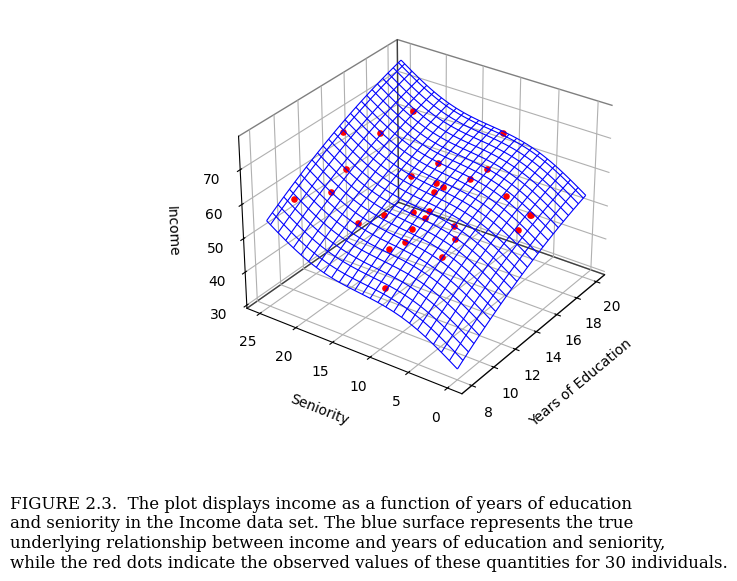

In [9]:
# ============================================================
# 3D 曲面 + 红色散点 + 图注
# 目标：模拟教材中的 "income - education - seniority" 图
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# ------------------------------------------------------------
# 1. 设定随机种子，保证结果可复现
# ------------------------------------------------------------
np.random.seed(123)

# ------------------------------------------------------------
# 2. 构造二维网格
#    x: years of education
#    y: seniority
# ------------------------------------------------------------
edu_grid = np.linspace(8, 20, 50)
sen_grid = np.linspace(0, 25, 50)

EDU, SEN = np.meshgrid(edu_grid, sen_grid)

# ------------------------------------------------------------
# 3. 构造一个“真实”非线性曲面
#    这里只是为了演示，故意设计得稍微有点弯曲
# ------------------------------------------------------------
INCOME_TRUE = (
    20
    + 1.8 * EDU
    + 0.9 * SEN
    - 0.06 * (EDU - 14) ** 2
    + 2.5 * np.sin(SEN / 4)
)

# ------------------------------------------------------------
# 4. 随机生成 30 个观测点
#    这些点来自真实曲面，再叠加随机扰动
# ------------------------------------------------------------
n = 30

edu_obs = np.random.uniform(8, 20, n)
sen_obs = np.random.uniform(0, 25, n)

income_obs = (
    20
    + 1.8 * edu_obs
    + 0.9 * sen_obs
    - 0.06 * (edu_obs - 14) ** 2
    + 2.5 * np.sin(sen_obs / 4)
    + np.random.normal(0, 2.5, n)   # 加入噪声
)

# ------------------------------------------------------------
# 5. 开始绘图
# ------------------------------------------------------------
fig = plt.figure(figsize=(10, 6.8))
ax = fig.add_subplot(111, projection='3d')

# ------------------------------------------------------------
# 5.1 绘制蓝色网格曲面
#     rstride / cstride 控制网格疏密
# ------------------------------------------------------------
ax.plot_wireframe(
    EDU, SEN, INCOME_TRUE,
    rstride=2, cstride=2,
    color='blue',
    linewidth=0.8
)

# ------------------------------------------------------------
# 5.2 叠加红色观测点
# ------------------------------------------------------------
ax.scatter(
    edu_obs, sen_obs, income_obs,
    color='red',
    s=14,
    depthshade=False
)

# ------------------------------------------------------------
# 6. 设置坐标轴标签
# ------------------------------------------------------------
ax.set_xlabel('Years of Education', labelpad=10)
ax.set_ylabel('Seniority', labelpad=10)
ax.set_zlabel('Income', labelpad=8)

# ------------------------------------------------------------
# 7. 调整视角
#    elev 控制俯仰角
#    azim 控制水平旋转角
# ------------------------------------------------------------
ax.view_init(elev=30, azim=-145)

# ------------------------------------------------------------
# 8. 去掉背景填充色，使图形更像教材插图
# ------------------------------------------------------------
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False

# 可选：让 pane 边框更明显一些
ax.xaxis.pane.set_edgecolor('black')
ax.yaxis.pane.set_edgecolor('black')
ax.zaxis.pane.set_edgecolor('black')

# ------------------------------------------------------------
# 9. 调整边距，为下方 caption 留出空间
# ------------------------------------------------------------
plt.subplots_adjust(bottom=0.28)

# ------------------------------------------------------------
# 10. 添加图注
#     这里直接用 fig.text 写在图下方
# ------------------------------------------------------------
caption = (
    "FIGURE 2.3.  The plot displays income as a function of years of education\n"
    "and seniority in the Income data set. The blue surface represents the true\n"
    "underlying relationship between income and years of education and seniority,\n"
    "while the red dots indicate the observed values of these quantities for 30 individuals."
)

fig.text(
    0.10, 0.06, caption,
    fontsize=12,
    family='serif',
    color='black'
)

# ------------------------------------------------------------
# 11. 显示图形
# ------------------------------------------------------------
plt.show()

# ------------------------------------------------------------
# 12. 可选：导出图片
# ------------------------------------------------------------
# fig.savefig("income_surface_plot.png", dpi=300, bbox_inches='tight')

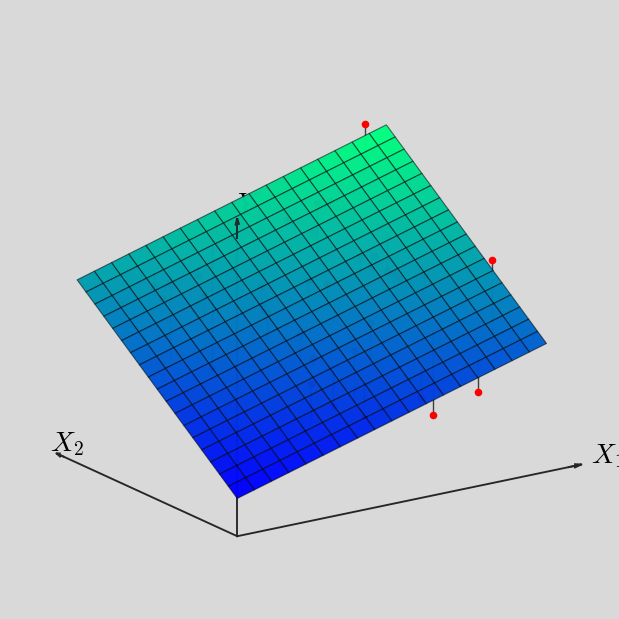

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon
from matplotlib.collections import PatchCollection, LineCollection

# ============================================================
# OLS 示意图：采用“手工投影 + 2D 绘图”的方式
# 说明：
# 1. 不使用 matplotlib 的 mplot3d
# 2. 这样更容易画出类似教材中的干净插图风格
# 3. 代码中的参数（视角、平面大小、点的位置）都可以继续微调
# ============================================================

# ------------------------------------------------------------
# 1. 全局设置
# ------------------------------------------------------------
plt.rcParams["font.family"] = "serif"
plt.rcParams["mathtext.fontset"] = "cm"

# ------------------------------------------------------------
# 2. 定义“屏幕投影基向量”
#    解释：
#    - e1 决定 X1 轴在屏幕上的方向
#    - e2 决定 X2 轴在屏幕上的方向
#    - ey 决定 Y 轴在屏幕上的方向
#    这三个向量不是三维空间里的标准基，而是“投影到屏幕后的方向”
# ------------------------------------------------------------
e1 = np.array([1.45, 0.28])    # X1：向右下方延伸
e2 = np.array([-1.00, 0.62])   # X2：向左上方延伸
ey = np.array([0.00, 1.22])    # Y ：基本竖直向上

# ------------------------------------------------------------
# 3. 定义投影函数
#    输入：
#      x1, x2, y  可以是标量，也可以是 numpy 数组
#    输出：
#      屏幕上的二维坐标 (u, v)
# ------------------------------------------------------------
def proj(x1, x2, y):
    u = e1[0] * x1 + e2[0] * x2 + ey[0] * y
    v = e1[1] * x1 + e2[1] * x2 + ey[1] * y
    return np.column_stack([u, v])

# ------------------------------------------------------------
# 4. 定义回归平面
#    y_hat = b0 + b1*x1 + b2*x2
#    这里的系数可以调，以改变平面倾斜程度
# ------------------------------------------------------------
b0 = 0.40
b1 = 0.23
b2 = 0.36

def yhat(x1, x2):
    return b0 + b1 * x1 + b2 * x2

# ------------------------------------------------------------
# 5. 构造平面网格
#    为了让网格看起来均匀、像教材插图，
#    这里直接构造规则网格，然后逐个小格填色
# ------------------------------------------------------------
x1_min, x1_max = 0.0, 8.0
x2_min, x2_max = 0.0, 8.0

nx, ny = 18, 18
x1g = np.linspace(x1_min, x1_max, nx + 1)
x2g = np.linspace(x2_min, x2_max, ny + 1)

# ------------------------------------------------------------
# 6. 构造平面小方块（patches）
#    每个小方块：
#    - 在 3D 中有 4 个角点
#    - 经过投影后，在 2D 中变成一个四边形
#    - 用小方块中心处的 y_hat 决定颜色
# ------------------------------------------------------------
patches = []
face_values = []

for i in range(nx):
    for j in range(ny):
        xa, xb = x1g[i], x1g[i + 1]
        ya, yb = x2g[j], x2g[j + 1]

        # 四个角点在平面上的高度
        z11 = yhat(xa, ya)
        z21 = yhat(xb, ya)
        z22 = yhat(xb, yb)
        z12 = yhat(xa, yb)

        # 投影到二维平面
        poly2d = proj(
            np.array([xa, xb, xb, xa]),
            np.array([ya, ya, yb, yb]),
            np.array([z11, z21, z22, z12])
        )

        patches.append(Polygon(poly2d, closed=True))

        # 用中心点的高度作为该小格的颜色值
        xc = 0.5 * (xa + xb)
        yc = 0.5 * (ya + yb)
        face_values.append(yhat(xc, yc))

face_values = np.array(face_values)

# 归一化颜色值
zmin = yhat(x1_min, x2_min)
zmax = yhat(x1_max, x2_max)
face_values_norm = (face_values - zmin) / (zmax - zmin)

# ------------------------------------------------------------
# 7. 构造网格线
#    为了得到类似书中的黑色网格，需要把横纵网格线单独画出来
# ------------------------------------------------------------
grid_segments = []

# x1 方向网格线：固定 x2，改变 x1
for y0 in x2g:
    x_line = np.linspace(x1_min, x1_max, 200)
    y_line = np.full_like(x_line, y0)
    z_line = yhat(x_line, y_line)
    p = proj(x_line, y_line, z_line)
    segs = np.stack([p[:-1], p[1:]], axis=1)
    grid_segments.extend(segs)

# x2 方向网格线：固定 x1，改变 x2
for x0 in x1g:
    y_line = np.linspace(x2_min, x2_max, 200)
    x_line = np.full_like(y_line, x0)
    z_line = yhat(x_line, y_line)
    p = proj(x_line, y_line, z_line)
    segs = np.stack([p[:-1], p[1:]], axis=1)
    grid_segments.extend(segs)

# ------------------------------------------------------------
# 8. 手工指定观测点
#    这里不再随机生成，而是手工布点。
#    原因：
#    - 教材中的图往往是“示意性”的
#    - 手工布点更容易得到美观结果
# ------------------------------------------------------------
pts = np.array([
    [0.9, 1.2, -0.90],
    [1.4, 6.8,  0.55],
    [2.7, 6.0,  0.35],
    [4.0, 7.4,  0.70],
    [5.7, 6.8,  0.85],
    [7.0, 4.8,  0.45],
    [7.2, 2.3, -0.75],
    [6.0, 1.5, -0.55],
    [3.2, 2.2, -0.45],
    [2.2, 7.8,  0.90],
])

x1p = pts[:, 0]
x2p = pts[:, 1]
eps = pts[:, 2]

y_fit = yhat(x1p, x2p)
y_obs = y_fit + eps

# 平面上的点（残差线起点）
p_fit = proj(x1p, x2p, y_fit)

# 观测点（残差线终点）
p_obs = proj(x1p, x2p, y_obs)

# ------------------------------------------------------------
# 9. 坐标轴
#    手动画三根轴，避免默认三维坐标轴的杂乱感
# ------------------------------------------------------------
origin = proj(0.0, 0.0, 0.0)[0]
x1_end = proj(9.2, 0.0, 0.0)[0]
x2_end = proj(0.0, 9.0, 0.0)[0]
y_end  = proj(0.0, 0.0, 7.2)[0]

# ------------------------------------------------------------
# 10. 开始绘图
# ------------------------------------------------------------
fig, ax = plt.subplots(figsize=(8.4, 6.6), facecolor="#d9d9d9")
ax.set_facecolor("#d9d9d9")

# 平面小方块着色
pc = PatchCollection(
    patches,
    cmap="winter",
    edgecolor="none",
    linewidth=0.0,
    zorder=1
)
pc.set_array(face_values_norm)
ax.add_collection(pc)

# 网格线
lc = LineCollection(
    grid_segments,
    colors=[(0, 0, 0, 0.45)],
    linewidths=0.9,
    zorder=2
)
ax.add_collection(lc)

# 三根坐标轴
ax.annotate(
    "",
    xy=x1_end,
    xytext=origin,
    arrowprops=dict(arrowstyle="-|>", lw=1.6, color="0.20"),
    zorder=3
)

ax.annotate(
    "",
    xy=x2_end,
    xytext=origin,
    arrowprops=dict(arrowstyle="-|>", lw=1.6, color="0.20"),
    zorder=3
)

ax.annotate(
    "",
    xy=y_end,
    xytext=origin,
    arrowprops=dict(arrowstyle="-|>", lw=1.6, color="0.20"),
    zorder=3
)

# 轴标签
ax.text(
    x1_end[0] + 0.18, x1_end[1] - 0.02,
    r"$X_1$", fontsize=28, ha="left", va="center"
)

ax.text(
    x2_end[0] - 0.08, x2_end[1] + 0.14,
    r"$X_2$", fontsize=28, ha="center", va="center"
)

ax.text(
    y_end[0] + 0.06, y_end[1] + 0.10,
    r"$Y$", fontsize=28, ha="center", va="bottom"
)

# 残差线
for a, b in zip(p_fit, p_obs):
    ax.plot(
        [a[0], b[0]],
        [a[1], b[1]],
        color="0.25",
        lw=1.4,
        zorder=4
    )

# 红色观测点
ax.scatter(
    p_obs[:, 0], p_obs[:, 1],
    s=44,
    c="red",
    edgecolors="none",
    zorder=5
)

# ------------------------------------------------------------
# 11. 自动设置显示范围
# ------------------------------------------------------------
all_xy = np.vstack([
    np.array([origin, x1_end, x2_end, y_end]),
    p_obs,
    p_fit
])

xmin, ymin = all_xy.min(axis=0)
xmax, ymax = all_xy.max(axis=0)

pad_x = 0.7
pad_y = 0.7

ax.set_xlim(xmin - pad_x, xmax + pad_x)
ax.set_ylim(ymin - pad_y, ymax + pad_y)

# 保证比例一致，否则图形会被拉伸
ax.set_aspect("equal")

# 去掉边框与刻度
ax.axis("off")

plt.tight_layout(pad=0.4)
plt.show()

# 如需保存图片，取消下面一行注释即可
# plt.savefig("ols_plane_james_style.png", dpi=300, bbox_inches="tight", facecolor=fig.get_facecolor())

<iframe
  src="./figs/fig_fitted_plane_residuals.html"
  width="100%"
  height="650"
  style="border:none;"
></iframe>



## 3. 如果你想要“更像截图”的交互效果

更接近你截图风格的，一般建议用 `plotly`。它的优点是：

* 可以直接拖动旋转
* 可以缩放
* 鼠标悬停时显示坐标
* 更适合做网页演示或课堂演示

如果你的目标是：

* 讲义插图、论文附图：优先 `matplotlib`
* 网页演示、交互式教学：优先 `plotly`

## 4. 这类图还能继续扩展什么

你这个图还可以继续扩展成几种常见版本：

* 改成非线性曲面，比如二次项模型
  $y = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \beta_3 x_1^2 + \beta_4 x_2^2 + u$
* 改成显示“正残差”和“负残差”的不同颜色
* 给每个点加编号或标签
* 叠加真实平面与拟合平面，比较模型误差
* 做成动画，展示参数变化时平面如何旋转

## 5. 结论

可以，而且并不难。

若你的目标只是“能画出来”，`matplotlib` 已经足够；若你希望做出和截图非常接近的交互式版本，`plotly` 更合适。

你要是愿意，我下一步可以直接给你一份 `plotly` 版本代码，做成和这张图更接近的可旋转交互图。
